## TELCO CHURN

Telco Churn dataset is a datasets published by IBM. It contains information about a fictional telecommunications company's customers and whether the cancelled their subscription or stayed

Customers who left last month month is called **Churn**

**Goal** : Predict behaviour to retain customers.


### Import neccessary libraries 


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


### Load data

PS: The data is already processed. 



In [34]:

BASE_DIR = Path().resolve().parent

df = pd.read_csv(BASE_DIR /'data'/'raw'/'WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head() # the first 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
print(f"rows :", df.shape[0])
print(f"columns :", df.shape[1])
df.describe(include='all')

rows : 7043
columns : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


**The datasets can be divided into three feature groups:**

- Numerical : represents continuous values such as tenure (months as customers), monthly charges, and total charhges.

- Binary : represents yes/no variables such as whether a customer has phone services, online security or tech support.

- Categorial : represents discrete groups such as a contract type (month-to-month, one year, two year), payment method, and internet service type.

Understanding these distinctions is important as each group may require different preprocessing steps and behave differently during training model.



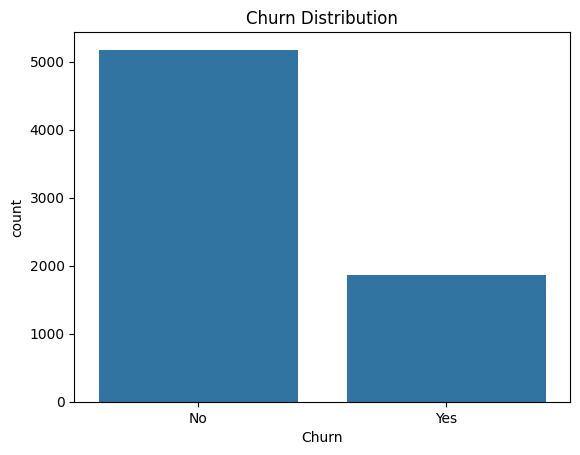

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [36]:
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()


churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_pct.round(1))

Notes : The target variable is higly inbalanced. The majority of customers did not churn, while a small fraction did. This class imbalanced is important to keep in mind during model training, as naive model could achieve high accuracy by predicting the majority class every time.

### Binary Encoding


In [37]:
# Binary categorial colums (Yes/No)

binary_cols =[
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'
]

# Map Yes/No and Male/Female to 0/1
df[binary_cols] = df[binary_cols].replace({
    'Yes' : 1, 'No' : 0,
    'Male' : 1, 'Female' : 0
}).astype(int)


### Categorial colums

One-hot encoding is a technique for converting categorical text variables into a numerical format that machine learning models can understand, since most algorithms cannot work directly with string values.

Each unique category in a column gets its own binary column with a value of 1 or 0.

In [38]:
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# One-hot encode
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


### Clean data


In [39]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [40]:
df = df.drop('customerID', axis=1)

In [41]:
bools_cols = df.select_dtypes(include='bool').columns
df[bools_cols] = df[bools_cols].astype(int)

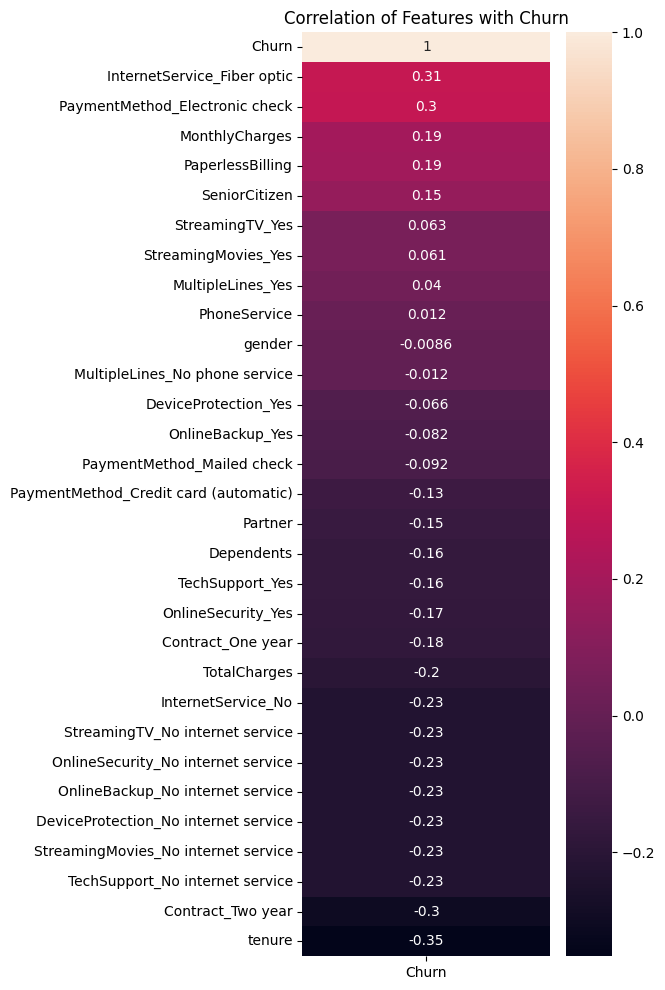

In [42]:
# Compute correlation matrix only for numeric columns

corr_matrix = df.corr(numeric_only=True)

churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

plt.figure(figsize=(4,12))
sns.heatmap(churn_corr, annot=True)
plt.title('Correlation of Features with Churn')
plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb 
import time


# Prepare data 
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

THRESHOLD = 0.3


### RandomForest Classifier

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=1
)

rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.885     0.769     0.823      1035
           1      0.531     0.725     0.613       374

    accuracy                          0.757      1409
   macro avg      0.708     0.747     0.718      1409
weighted avg      0.791     0.757     0.767      1409



In [45]:
from xgboost import XGBClassifier


scale_pos_weight = (y_train ==0).sum() / (y_train ==1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8, 
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_time = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training time : {train_time:.2f} seconds")


# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD)
pred_time = time.time() - start_time
print(f"Prediction time : {pred_time:.2f} seconds")


print(classification_report(y_test, y_pred, digits=3))

Training time : 1.14 seconds
Prediction time : 1.15 seconds
              precision    recall  f1-score   support

           0      0.912     0.697     0.790      1035
           1      0.492     0.813     0.613       374

    accuracy                          0.727      1409
   macro avg      0.702     0.755     0.701      1409
weighted avg      0.800     0.727     0.743      1409



In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:,1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh' :<8}{'Prec_1' :<8}{'Rec_1' :<8}{'F1_1' :<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.481   0.853   0.615   
0.3     0.492   0.813   0.613   
0.35    0.504   0.789   0.615   
0.4     0.517   0.762   0.616   
0.45    0.536   0.722   0.615   
0.5     0.543   0.690   0.608   


### Hyperparameter Tuning 

In [49]:
import optuna #
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split


def objective(trial):
    params = {
        "n_estimators" : trial.suggest_int("n_estimators", 300, 800),
        "learning_rate" : trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth" : trial.suggest_int("max_depth", 3, 10),
        "subsample" : trial.suggest_float("subsample", 0.5, 1.0),
        "eval_metric" :"logloss",
        "scale_pos_weight" : (y_train == 0).sum() / (y_train == 1).sum(),
        "random_state" : 42,
        "n_jobs" :-1
        
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:,1]
    y_pred = (proba >= THRESHOLD).astype(int) # Keep your tuned threshold
    return recall_score(y_test, y_pred, pos_label=1) # Optimize recall

# Run optuna
best_param = optuna.create_study(direction="maximize")
best_param.optimize(objective, n_trials=30)

print("Best Params :", best_param.best_params)
print("Best Recall :", best_param.best_value)


[I 2026-03-31 18:31:52,858] A new study created in memory with name: no-name-e2f345b7-64c2-46b5-a091-35711b87b825
[I 2026-03-31 18:31:54,894] Trial 0 finished with value: 0.6524064171122995 and parameters: {'n_estimators': 756, 'learning_rate': 0.19240494555460902, 'max_depth': 8, 'subsample': 0.9156830547133474}. Best is trial 0 with value: 0.6524064171122995.
[I 2026-03-31 18:31:55,639] Trial 1 finished with value: 0.8422459893048129 and parameters: {'n_estimators': 561, 'learning_rate': 0.054271726672742326, 'max_depth': 5, 'subsample': 0.9206044243693006}. Best is trial 1 with value: 0.8422459893048129.
[I 2026-03-31 18:31:56,846] Trial 2 finished with value: 0.6470588235294118 and parameters: {'n_estimators': 614, 'learning_rate': 0.1733409102012671, 'max_depth': 9, 'subsample': 0.8397376805614731}. Best is trial 1 with value: 0.8422459893048129.
[I 2026-03-31 18:31:57,583] Trial 3 finished with value: 0.7834224598930482 and parameters: {'n_estimators': 773, 'learning_rate': 0.120

Best Params : {'n_estimators': 311, 'learning_rate': 0.010085430626178653, 'max_depth': 4, 'subsample': 0.5612795922935953}
Best Recall : 0.9331550802139037


In [55]:

# The best params
best_params = {
    "n_estimators" : 311,
    "learning_rate" : 0.01,
    "max_depth" : 4,
    "subsample" : 0.56,
    "scale_pos_weight" : scale_pos_weight,
    "random_state" : 42,
    "n_jobs" :- 1,
    "eval_metric" : "logloss",
}

# Create model from best params
xgb = XGBClassifier(**best_params)

#
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f'Training time: {train_time:.2f} seconds')

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time : {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

Training time: 0.36 seconds
Prediction time : 0.0141 seconds
              precision    recall  f1-score   support

           0      0.958     0.550     0.699      1035
           1      0.428     0.933     0.587       374

    accuracy                          0.652      1409
   macro avg      0.693     0.741     0.643      1409
weighted avg      0.817     0.652     0.669      1409



- Recall (class 1) : 0.058. It is the highest I have seen so far

- Precision (class 1) : 0.428 (low - many loyal customers are being flagged)

Interpretation

- This model is catching almost all churners, which is great if you are running aggresive retention campaigns and the cost of contacting non-churns is low.

- But the low precision means more than half of the people you are target won't actually churn.
